In [4]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# EDA🧐 

In [5]:
df = pd.read_csv("train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
df.shape

(404290, 6)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404290 non-null  int64
 1   qid1          404290 non-null  int64
 2   qid2          404290 non-null  int64
 3   question1     404289 non-null  str  
 4   question2     404288 non-null  str  
 5   is_duplicate  404290 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [8]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print(df["is_duplicate"].value_counts())

is_duplicate
0    255027
1    149263
Name: count, dtype: int64


In [11]:
print(f"{(df["is_duplicate"].value_counts()/df['is_duplicate'].count())*100}%")

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64%


<Axes: xlabel='is_duplicate'>

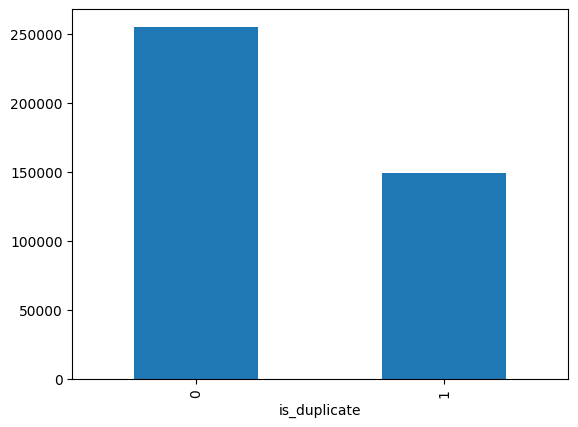

In [12]:
df['is_duplicate'].value_counts().plot(kind='bar')

In [13]:
qid = pd.Series(df['qid1'].to_list() + df['qid2'].to_list())
print('Number of Unique questions',np.unique(qid))
x=qid.value_counts()>1
print("Number of questions getting repeated :",x[x].shape[0])

Number of Unique questions [     1      2      3 ... 537931 537932 537933]
Number of questions getting repeated : 111780


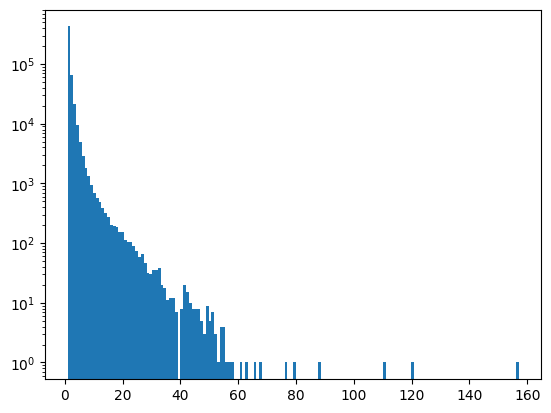

In [14]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

# Apply Only BOW & 👀Accuracy

In [15]:
ques_df = df[["question1","question2"]]

In [16]:
ques_df.head()

,question1,question2
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?


In [17]:
ques_df.sample(10)

,question1,question2
115334,Can I delete my own question after it's been a...,How do you delete a question you asked on Quora
291685,Do apps like Clean Master actually boost your ...,Do apps that clean junk like 360 Security or C...
258793,Why isn't dicarbon an organic compound?,Does anyone own the exactly similar rambo 2 kn...
218669,How much weight can I lose if I only drink die...,Will I lose weight by only drinking water?
219,How can I learn computer security?,How can I get started to learn information sec...
361617,Which is the best place to prepare for the IELTS?,How can I pass the IELTS?
125402,What makes a face good looking?,What makes a face pleasing to look at?
964,How does Anil Ambani benefit from Rafel fighte...,What is bought more online?
134165,What's the most romantic thing anyone has ever...,What is the most romantic thing you have ever ...
151456,What is the best jazz bar in New York City?,What are the best jazz clubs in New York?


In [18]:
questions = list(ques_df['question1']) + list(ques_df['question2'])
questions = [str(q) if isinstance(q, str) else "" for q in questions]
questions

['What is the step by step guide to invest in share market in india?',
 'What is the story of Kohinoor (Koh-i-Noor) Diamond?',
 'How can I increase the speed of my internet connection while using a VPN?',
 'Why am I mentally very lonely? How can I solve it?',
 'Which one dissolve in water quikly sugar, salt, methane and carbon di oxide?',
 'Astrology: I am a Capricorn Sun Cap moon and cap rising...what does that say about me?',
 'Should I buy tiago?',
 'How can I be a good geologist?',
 'When do you use シ instead of し?',
 'Motorola (company): Can I hack my Charter Motorolla DCX3400?',
 'Method to find separation of slits using fresnel biprism?',
 'How do I read and find my YouTube comments?',
 'What can make Physics easy to learn?',
 'What was your first sexual experience like?',
 'What are the laws to change your status from a student visa to a green card in the US, how do they compare to the immigration laws in Canada?',
 'What would a Trump presidency mean for current international 

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=3000)
q1_arr,q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [ ]:
temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)
temp_df = pd.concat([temp_df1,temp_df2],axis=1)

In [25]:
temp_df.shape

(404290, 6001)

In [26]:
temp_df['is_duplicate'] = df['is_duplicate']

In [27]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
new_df, _ = train_test_split(temp_df, train_size=200000, stratify=temp_df.iloc[:, -1], random_state=42)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(new_df.iloc[:,0:-1].values,new_df.iloc[:,-1].values,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_jobs=-1,random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)